# Visual Question Answering (VQA) using BLIP

**Author:** Hamayl Zahid  
**Model:** `Salesforce/blip-vqa-base` (pretrained)  
**Framework:** PyTorch + HuggingFace Transformers  

---

## Overview
This project demonstrates Visual Question Answering (VQA), where the model can answer natural language questions about an input image. The system uses the **BLIP (Bootstrapped Language Image Pretraining)** model from Salesforce.

---

## Features
- Pretrained BLIP model for state-of-the-art VQA.
- Handles any RGB image input.
- Simple function interface: provide an image and a question, get an answer.
- Device-aware execution: automatically uses GPU if available.

---

In [1]:
# ============================

import torch
from PIL import Image
from transformers import BlipProcessor, BlipForQuestionAnswering

In [2]:
# ----------------------------
# 1. DEVICE
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cpu


In [3]:
# ----------------------------
# 2. LOAD MODEL + PROCESSOR
# ----------------------------
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

In [4]:
# ----------------------------
# 3. FUNCTION TO ANSWER QUESTION
# ----------------------------
def vqa_answer(image_path, question):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    inputs = processor(image, question, return_tensors="pt").to(device)

    # Forward pass
    with torch.no_grad():
        output = model.generate(**inputs)

    # Decode prediction
    answer = processor.decode(output[0], skip_special_tokens=True)
    return answer

#  VQA Test: Multiple Images & Multiple Questions

This section allows you to interactively test the **BLIP VQA model** on multiple images.  

---

## Features
- Upload **two or more images** at once.
- For each image, ask **any number of questions**.
- Displays the uploaded image for visual reference.
- Automatically generates answers using the `vqa_answer()` function.

---

## Instructions
1. Click the **Upload** button and select 2 or more images.  
2. For each image, input the number of questions you want to ask.  
3. Enter each question one by one.  
4. The model will display both the **question** and the **predicted answer**.  

> ⚠️ Ensure images are in RGB format and the file types are supported (e.g., JPG, PNG).  


Upload 2 or more images:


Saving images1.jfif to images1 (1).jfif
Saving images (4).jfif to images (4) (5).jfif

IMAGE: images1 (1).jfif


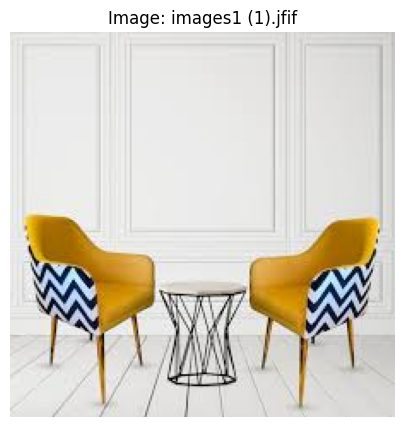

How many questions do you want to ask about images1 (1).jfif? 2

Enter Question 1: How many chairs are in picture?
Q1: How many chairs are in picture?
A1: two

Enter Question 2: color of chairs?
Q2: color of chairs?
A2: yellow

IMAGE: images (4) (5).jfif


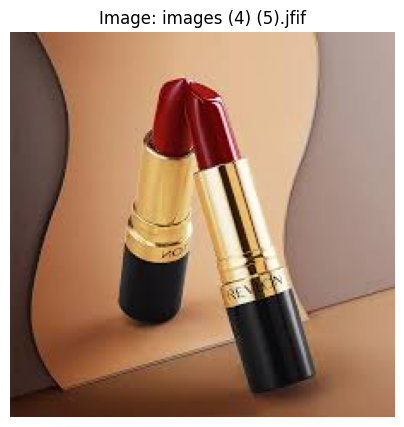

How many questions do you want to ask about images (4) (5).jfif? 2

Enter Question 1: Name the product shown in picture?
Q1: Name the product shown in picture?
A1: lipstick

Enter Question 2: what is color of lipstick?
Q2: what is color of lipstick?
A2: red


In [11]:
# ---------------------------------------------------------
# 4. TEST (MULTIPLE IMAGES + MULTIPLE QUESTIONS)
# ---------------------------------------------------------
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Upload multiple images
print("Upload 2 or more images:")
uploaded = files.upload()

# Convert uploaded dict to list of file names
image_files = list(uploaded.keys())

# Loop over each uploaded image
for img_path in image_files:
    print("\n==========================================")
    print(f"IMAGE: {img_path}")
    print("==========================================")

    # Load and display image
    image = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Image: {img_path}")
    plt.show()

    # Ask how many questions user wants
    num_q = int(input(f"How many questions do you want to ask about {img_path}? "))

    # Ask questions one by one
    for i in range(num_q):
        question = input(f"\nEnter Question {i+1}: ")
        answer = vqa_answer(img_path, question)

        print(f"Q{i+1}: {question}")
        print(f"A{i+1}: {answer}")


# Conclusion

The Visual Question Answering (VQA) system using **BLIP (`Salesforce/blip-vqa-base`)** successfully demonstrates how AI can understand and answer questions about images.  

---


## Future Enhancements
- Extend to **batch processing** for larger datasets.
- Integrate **confidence scores** for answers.
- Fine-tune the model on **custom domain-specific images** for better accuracy.
- Add **visual highlights** on images showing areas relevant to the answer (explainability).  

---

 This notebook serves as a foundation for building advanced AI systems capable of **interpreting and reasoning about visual content**.
